Customer Segmentation and Churn Pattern Analytics in European Banking

Tools Used - 1. Python 2. Pandas 3. Numpy 4. Matplotlib 5. Seaborn 6. Scikit-learn 7. Excel 8. Power BI 9. Tableau 10. SQL

Objective: To analyze customer churn patterns in European banking by identifying high-risk customer segments based on geography, age, gender, balance, tenure, activity status, and product usage. The project aims to provide actionable business insights to improve customer retention strategies.






In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 10)

print("Libraries imported successfully!")

Libraries imported successfully!


In [7]:
from google.colab import files
uploaded = files.upload()

Saving European_Bank.csv to European_Bank.csv


In [8]:
df = pd.read_csv("European_Bank.csv")
df.head()

,Year,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,2025,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2025,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,2025,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,2025,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,2025,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [9]:
print("Dataset Shape:", df.shape)
print("\n")
df.info()

Dataset Shape: (10000, 14)


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Year             10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB


In [10]:
df.isnull().sum()

,0
Year,0
CustomerId,0
Surname,0
CreditScore,0
Geography,0
...,...
NumOfProducts,0
HasCrCard,0
IsActiveMember,0
EstimatedSalary,0


In [11]:
df.duplicated().sum()

np.int64(0)

In [12]:
df = df.drop(columns=['Unnamed: 14', 'Unnamed: 15'], errors='ignore')

In [13]:
df.columns

Index(['Year', 'CustomerId', 'Surname', 'CreditScore', 'Geography', 'Gender',
       'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard',
       'IsActiveMember', 'EstimatedSalary', 'Exited'],
      dtype='object')

In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Year             10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB


In [15]:
df.describe()

,Year,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,10000.0,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,2025.0,1.569094e+07,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700
std,0.0,7.193619e+04,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769
min,2025.0,1.556570e+07,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000
25%,2025.0,1.562853e+07,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000
50%,2025.0,1.569074e+07,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000
75%,2025.0,1.575323e+07,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000
max,2025.0,1.581569e+07,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000


# Exploratory Data Analysis (EDA)

##1. Overall Customer Churn Distribution

In this section, we analyze the overall customer churn to understand the proportion of customers who have stayed with the bank versus those who have exited.

In [16]:
# Count of retained and churned customers
df['Exited'].value_counts()

,count
Exited,
0,7963
1,2037


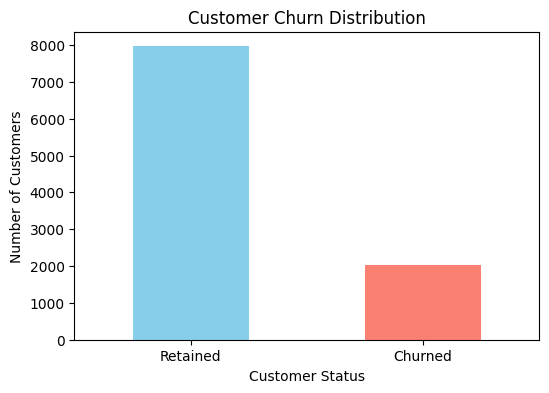

In [17]:
# Visualize Overall Customer Churn Distribution

import matplotlib.pyplot as plt
plt.figure(figsize=(6,4))

df['Exited'].value_counts().plot(kind='bar',color=['skyblue', 'salmon'])

plt.title("Customer Churn Distribution")
plt.xlabel("Customer Status")
plt.ylabel("Number of Customers")
plt.xticks([0,1], ['Retained', 'Churned'], rotation=0)

plt.show()

In [18]:
# Overall Churn Rate

churn_percentage = df['Exited'].mean() * 100
print(f"Overall Churn Rate: {churn_percentage:.2f}%")

Overall Churn Rate: 20.37%


### Business Insight

- Out of 10,000 customers, 7,963 remained with the bank while 2,037 customers exited.
- The overall customer churn rate is **20.37%**, indicating that approximately **1 in every 5 customers** left the bank.
- This suggests that customer retention should be a strategic priority for the bank.

## 2. Geography-wise Customer Churn Analysis

This section analyzes customer churn across different European countries to identify regions with higher customer attrition.

In [19]:
# Number of customers by geography

df['Geography'].value_counts()

,count
Geography,
France,5014
Germany,2509
Spain,2477


In [20]:
# Churn rate by geography

geo_churn = df.groupby('Geography')['Exited'].mean() * 100
geo_churn

,Exited
Geography,
France,16.154767
Germany,32.443204
Spain,16.673395


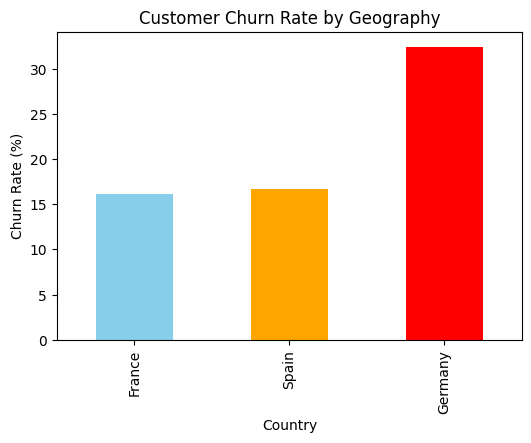

In [21]:
plt.figure(figsize=(6,4))

geo_churn.sort_values().plot(kind='bar',color=['skyblue','orange','red'])

plt.title("Customer Churn Rate by Geography")
plt.xlabel("Country")
plt.ylabel("Churn Rate (%)")

plt.show()

### Business Insight

- Germany has the highest customer churn rate among all three countries.
- France and Spain have significantly lower churn rates.
- The bank should prioritize customer retention strategies in Germany to reduce customer losses.

## 3. Gender-wise Customer Churn Analysis

This section analyzes customer churn across male and female customers to identify whether gender has any significant impact on customer attrition.

In [22]:
# Number of customers by gender

df['Gender'].value_counts()

,count
Gender,
Male,5457
Female,4543


In [23]:
# Churn rate by gender

gender_churn = df.groupby('Gender')['Exited'].mean() * 100
print(gender_churn)

Gender
Female    25.071539
Male      16.455928
Name: Exited, dtype: float64


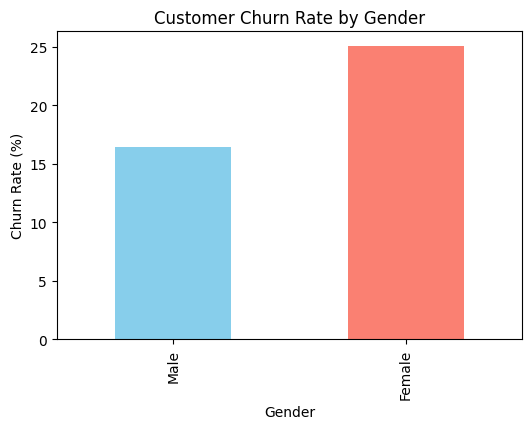

In [24]:
plt.figure(figsize=(6,4))

gender_churn.sort_values().plot(kind='bar',color=['skyblue','salmon'])

plt.title("Customer Churn Rate by Gender")
plt.xlabel("Gender")
plt.ylabel("Churn Rate (%)")

plt.show()

### Business Insight

- Female customers have a higher churn rate (25.07%) than male customers (16.46%).
- This suggests that female customers may be more likely to leave the bank.
- The bank should further investigate the reasons behind this difference and consider targeted retention strategies.

## 4. Age-wise Customer Churn Analysis

This section categorizes customers into age groups and analyzes the churn rate across different age segments.

In [25]:
# Create Age Group

df['Age_Group'] = pd.cut(df['Age'],bins=[0, 30, 45, 60, 100],labels=['<30', '30-45', '46-60', '60+'])
df[['Age', 'Age_Group']].head()

,Age,Age_Group
0,42,30-45
1,41,30-45
2,42,30-45
3,39,30-45
4,43,30-45


In [26]:
age_churn = df.groupby('Age_Group')['Exited'].mean() * 100
print(age_churn)

Age_Group
<30       7.520325
30-45    15.740584
46-60    51.123254
60+      24.784483
Name: Exited, dtype: float64


/tmp/ipykernel_4507/560268165.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  age_churn = df.groupby('Age_Group')['Exited'].mean() * 100


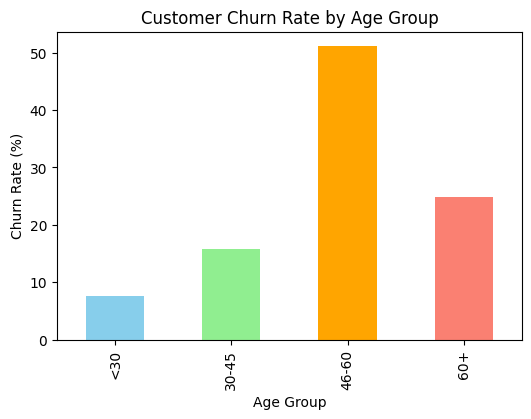

In [27]:
plt.figure(figsize=(6,4))

age_churn.plot(kind='bar',color=['skyblue','lightgreen','orange','salmon'])

plt.title("Customer Churn Rate by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Churn Rate (%)")

plt.show()

### Business Insight

- The churn rate varies across different age groups.
- Identifying the age segment with the highest churn helps the bank design targeted customer retention strategies.
- Marketing campaigns and customer engagement initiatives can be tailored based on age-specific behavior.

## 5. Active Member vs Customer Churn

This section examines whether active customers are less likely to churn compared to inactive customers.

In [28]:
# Churn rate by activity status

active_churn = df.groupby('IsActiveMember')['Exited'].mean() * 100
print(active_churn)

IsActiveMember
0    26.850897
1    14.269074
Name: Exited, dtype: float64


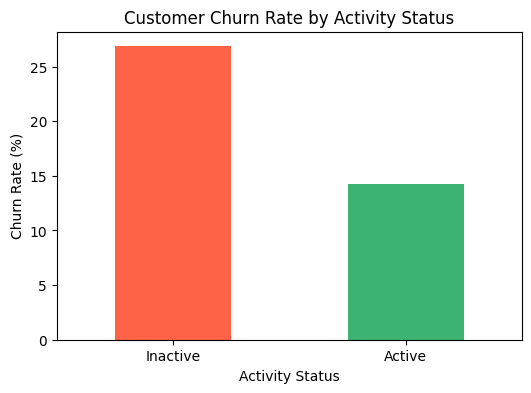

In [29]:
plt.figure(figsize=(6,4))

active_churn.plot(kind='bar',color=['tomato', 'mediumseagreen'])

plt.title("Customer Churn Rate by Activity Status")
plt.xlabel("Activity Status")
plt.ylabel("Churn Rate (%)")
plt.xticks([0,1], ['Inactive', 'Active'], rotation=0)

plt.show()

### Business Insight

- Inactive customers have a significantly higher churn rate than active customers.
- Customer engagement appears to play an important role in retention.
- The bank should encourage inactive customers to use banking services more frequently through personalized offers and engagement campaigns.

## 6. Number of Products vs Customer Churn

This section analyzes how the number of bank products owned by a customer influences customer churn.

In [30]:
# Churn rate by number of products

product_churn = df.groupby('NumOfProducts')['Exited'].mean() * 100
print(product_churn)

NumOfProducts
1     27.714398
2      7.581699
3     82.706767
4    100.000000
Name: Exited, dtype: float64


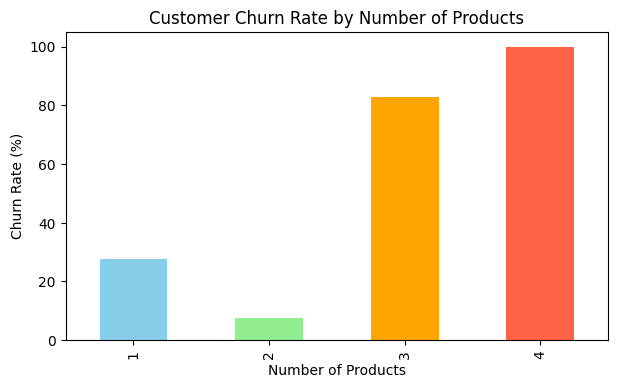

In [31]:
plt.figure(figsize=(7,4))

product_churn.plot(kind='bar',color=['skyblue', 'lightgreen', 'orange', 'tomato'])

plt.title("Customer Churn Rate by Number of Products")
plt.xlabel("Number of Products")
plt.ylabel("Churn Rate (%)")

plt.show()

### Business Insight

- Customer churn differs across product ownership levels.
- Customers with certain product combinations are more likely to leave the bank.
- The bank should analyze product usage patterns and design targeted cross-selling and retention strategies.

## 7. Correlation Analysis

This section examines the relationships between numerical variables using a correlation heatmap. It helps identify which features have stronger positive or negative relationships with customer churn.

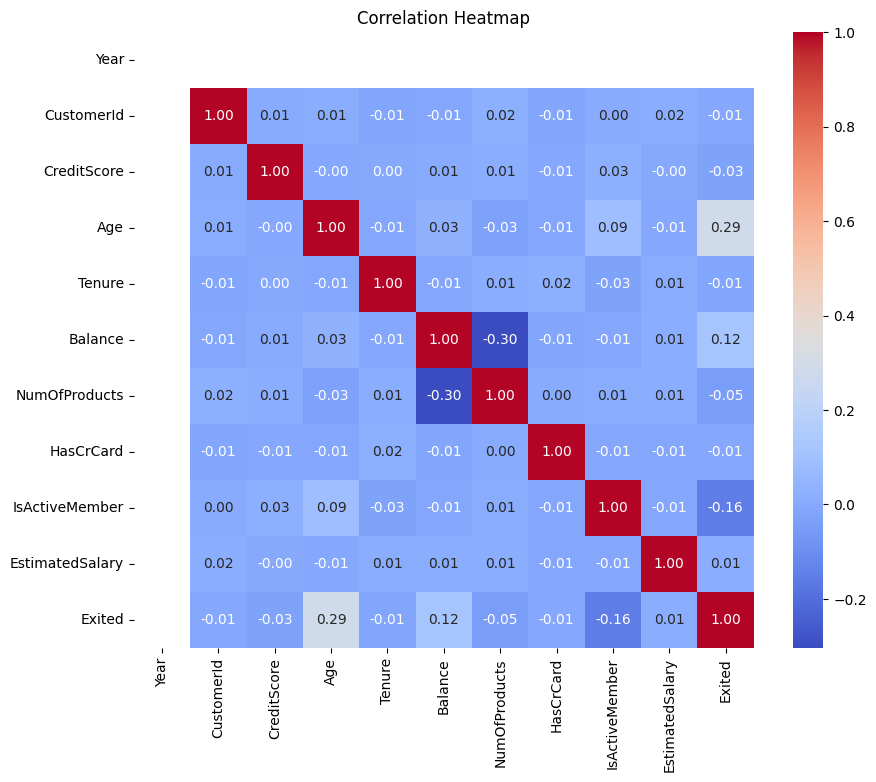

In [32]:
# Select only numerical columns
numeric_df = df.select_dtypes(include=['number'])

# Create correlation matrix
correlation_matrix = numeric_df.corr()

# Plot heatmap
plt.figure(figsize=(10, 8))

sns.heatmap(correlation_matrix,annot=True,cmap='coolwarm',fmt='.2f')

plt.title("Correlation Heatmap")
plt.show()



### Business Insight

- Age shows a positive relationship with customer churn, indicating that older customers are relatively more likely to exit.
- Active membership has a negative relationship with churn, suggesting active customers are more likely to stay.
- Most variables have weak correlations, indicating that customer churn is influenced by multiple factors rather than a single variable.

# EDA Summary

### Key Findings

- The overall customer churn rate is approximately 20.37%.
- Germany has the highest customer churn among the three countries.
- Female customers show a higher churn rate than male customers.
- Older customers tend to churn more frequently than younger customers.
- Inactive customers are significantly more likely to leave the bank.
- Customer churn varies based on the number of banking products owned.
- Correlation analysis indicates that customer churn is influenced by multiple factors rather than a single variable.

# Feature Engineering

This section creates additional customer segmentation variables that will be used in SQL analysis, dashboards, and customer segmentation.

# 9. Feature Engineering

Feature Engineering involves creating new variables from existing data to improve analysis and customer segmentation. In this section, we create Credit Score Bands, Balance Segments, and Tenure Groups.

In [33]:
# Create Credit Score Band

df['CreditScore_Band'] = pd.cut(df['CreditScore'],bins=[300, 580, 670, 850],labels=['Low', 'Medium', 'High'])
df[['CreditScore', 'CreditScore_Band']].head()

,CreditScore,CreditScore_Band
0,619,Medium
1,608,Medium
2,502,Low
3,699,High
4,850,High


In [34]:
# Create Balance Segment

df['Balance_Segment'] = pd.cut(df['Balance'],bins=[-1, 0, 100000, df['Balance'].max()],labels=['Zero Balance', 'Low Balance', 'High Balance'])
df[['Balance', 'Balance_Segment']].head()

,Balance,Balance_Segment
0,0.00,Zero Balance
1,83807.86,Low Balance
2,159660.80,High Balance
3,0.00,Zero Balance
4,125510.82,High Balance


In [35]:
# Create Tenure Group

df['Tenure_Group'] = pd.cut(df['Tenure'],bins=[-1, 2, 6, 10],labels=['New Customer', 'Mid-term Customer', 'Long-term Customer'])
df[['Tenure', 'Tenure_Group']].head()

,Tenure,Tenure_Group
0,2,New Customer
1,1,New Customer
2,8,Long-term Customer
3,1,New Customer
4,2,New Customer


In [36]:
df.head()

,Year,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Age_Group,CreditScore_Band,Balance_Segment,Tenure_Group
0,2025,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1,30-45,Medium,Zero Balance,New Customer
1,2025,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0,30-45,Medium,Low Balance,New Customer
2,2025,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1,30-45,Low,High Balance,Long-term Customer
3,2025,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0,30-45,High,Zero Balance,New Customer
4,2025,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0,30-45,High,High Balance,New Customer


# 10. Export Cleaned Dataset

The cleaned and feature-engineered dataset is exported for use in SQL, Power BI, Tableau, and Streamlit.

In [37]:
# Export cleaned dataset

df.to_csv("European_Bank_Cleaned.csv", index=False)
print("Cleaned dataset exported successfully!")

Cleaned dataset exported successfully!


# 11. Hypothesis Testing

## Hypothesis 1: Gender vs Customer Churn

In [38]:
from scipy.stats import chi2_contingency
import pandas as pd

### Null Hypothesis (H₀)

There is no significant relationship between Gender and Customer Churn.

### Alternative Hypothesis (H₁)

There is a significant relationship between Gender and Customer Churn.

In [39]:
gender_churn = pd.crosstab(df['Gender'], df['Exited'])
gender_churn

Exited,0,1
Gender,,
Female,3404,1139
Male,4559,898


In [40]:
chi2, p, dof, expected = chi2_contingency(gender_churn)
print("Chi-Square Statistic:", chi2)
print("P-value:", p)
print("Degrees of Freedom:", dof)

Chi-Square Statistic: 112.91857062096116
P-value: 2.2482100097131755e-26
Degrees of Freedom: 1


In [41]:
alpha = 0.05

if p < alpha:
    print("Reject the Null Hypothesis")
    print("There is a significant relationship between Gender and Customer Churn.")
else:
    print("Fail to Reject the Null Hypothesis")
    print("There is no significant relationship between Gender and Customer Churn.")

Reject the Null Hypothesis
There is a significant relationship between Gender and Customer Churn.


## Hypothesis 2: Geography vs Customer Churn

### Null Hypothesis (H₀)

There is no significant relationship between Geography and Customer Churn.

### Alternative Hypothesis (H₁)

There is a significant relationship between Geography and Customer Churn.

In [42]:
geo_churn = pd.crosstab(df['Geography'], df['Exited'])
geo_churn

Exited,0,1
Geography,,
France,4204,810
Germany,1695,814
Spain,2064,413


In [43]:
chi2, p, dof, expected = chi2_contingency(geo_churn)
print("Chi-Square Statistic:", chi2)
print("P-value:", p)
print("Degrees of Freedom:", dof)

Chi-Square Statistic: 301.25533682434536
P-value: 3.8303176053541544e-66
Degrees of Freedom: 2


In [44]:
alpha = 0.05

if p < alpha:
    print("Reject the Null Hypothesis")
    print("There is a significant relationship between Geography and Customer Churn.")
else:
    print("Fail to Reject the Null Hypothesis")
    print("There is no significant relationship between Geography and Customer Churn.")

Reject the Null Hypothesis
There is a significant relationship between Geography and Customer Churn.


## Hypothesis 3: Age Group vs Customer Churn

### Null Hypothesis (H₀)

There is no significant relationship between Age Group and Customer Churn.

### Alternative Hypothesis (H₁)

There is a significant relationship between Age Group and Customer Churn.

In [45]:
age_churn = pd.crosstab(df['Age_Group'], df['Exited'])
age_churn

Exited,0,1
Age_Group,,
<30,1820,148
30-45,4989,932
46-60,805,842
60+,349,115


In [46]:
chi2, p, dof, expected = chi2_contingency(age_churn)
print("Chi-Square Statistic:", chi2)
print("P-value:", p)
print("Degrees of Freedom:", dof)

Chi-Square Statistic: 1244.436081307657
P-value: 1.674608654984579e-269
Degrees of Freedom: 3


In [47]:
alpha = 0.05

if p < alpha:
    print("Reject the Null Hypothesis")
    print("There is a significant relationship between Age Group and Customer Churn.")
else:
    print("Fail to Reject the Null Hypothesis")
    print("There is no significant relationship between Age Group and Customer Churn.")

Reject the Null Hypothesis
There is a significant relationship between Age Group and Customer Churn.


## Hypothesis 4: Balance vs Customer Churn

### Null Hypothesis (H₀)

There is no significant difference in the average account balance between churned and retained customers.

### Alternative Hypothesis (H₁)

There is a significant difference in the average account balance between churned and retained customers.

In [48]:
from scipy.stats import ttest_ind

In [49]:
balance_churned = df[df['Exited'] == 1]['Balance']
balance_retained = df[df['Exited'] == 0]['Balance']

In [50]:
t_stat, p = ttest_ind(balance_churned, balance_retained)
print("T-Statistic:", t_stat)
print("P-value:", p)

T-Statistic: 11.936240300013841
P-value: 1.2755633191525477e-32


In [51]:
alpha = 0.05

if p < alpha:
    print("Reject the Null Hypothesis")
    print("There is a significant difference in the average account balance between churned and retained customers.")
else:
    print("Fail to Reject the Null Hypothesis")
    print("There is no significant difference in the average account balance between churned and retained customers.")

Reject the Null Hypothesis
There is a significant difference in the average account balance between churned and retained customers.


## Hypothesis 5: Credit Score vs Customer Churn

### Null Hypothesis (H₀)

There is no significant difference in the average credit score between churned and retained customers.

### Alternative Hypothesis (H₁)

There is a significant difference in the average credit score between churned and retained customers.

In [52]:
credit_churned = df[df['Exited'] == 1]['CreditScore']
credit_retained = df[df['Exited'] == 0]['CreditScore']

In [53]:
t_stat, p = ttest_ind(credit_churned, credit_retained)
print("T-Statistic:", t_stat)
print("P-value:", p)

T-Statistic: -2.7100778888729833
P-value: 0.006738213892192373


In [54]:
alpha = 0.05

if p < alpha:
    print("Reject the Null Hypothesis")
    print("There is a significant difference in the average credit score between churned and retained customers.")
else:
    print("Fail to Reject the Null Hypothesis")
    print("There is no significant difference in the average credit score between churned and retained customers.")

Reject the Null Hypothesis
There is a significant difference in the average credit score between churned and retained customers.


## Hypothesis 6: Estimated Salary vs Customer Churn

### Null Hypothesis (H₀)

There is no significant difference in the average estimated salary between churned and retained customers.

### Alternative Hypothesis (H₁)

There is a significant difference in the average estimated salary between churned and retained customers.

In [55]:
salary_churned = df[df['Exited'] == 1]['EstimatedSalary']
salary_retained = df[df['Exited'] == 0]['EstimatedSalary']

In [56]:
t_stat, p = ttest_ind(salary_churned, salary_retained)
print("T-Statistic:", t_stat)
print("P-value:", p)

T-Statistic: 1.209653638019264
P-value: 0.22644042802223352


In [57]:
alpha = 0.05

if p < alpha:
    print("Reject the Null Hypothesis")
    print("There is a significant difference in the average estimated salary between churned and retained customers.")
else:
    print("Fail to Reject the Null Hypothesis")
    print("There is no significant difference in the average estimated salary between churned and retained customers.")

Fail to Reject the Null Hypothesis
There is no significant difference in the average estimated salary between churned and retained customers.


# 12. Customer Segmentation

## Rule-Based Customer Segmentation

In [58]:
def customer_segment(row):

    if row['Exited'] == 1:
        return 'High-Risk Customer'

    elif row['IsActiveMember'] == 0:
        return 'Inactive Customer'

    elif row['Balance'] > df['Balance'].median():
        return 'High-Value Customer'

    else:
        return 'Loyal Customer'


df['Customer_Segment'] = df.apply(customer_segment, axis=1)

In [59]:
df[['CustomerId',
    'Balance',
    'IsActiveMember',
    'Exited',
    'Customer_Segment']].head(10)

,CustomerId,Balance,IsActiveMember,Exited,Customer_Segment
0,15634602,0.00,1,1,High-Risk Customer
1,15647311,83807.86,1,0,Loyal Customer
2,15619304,159660.80,0,1,High-Risk Customer
3,15701354,0.00,0,0,Inactive Customer
4,15737888,125510.82,1,0,High-Value Customer
5,15574012,113755.78,0,1,High-Risk Customer
6,15592531,0.00,1,0,Loyal Customer
7,15656148,115046.74,0,1,High-Risk Customer
8,15792365,142051.07,1,0,High-Value Customer
9,15592389,134603.88,1,0,High-Value Customer


In [60]:
segment_summary = df['Customer_Segment'].value_counts()
segment_summary

,count
Customer_Segment,
Inactive Customer,3547
Loyal Customer,2327
High-Value Customer,2089
High-Risk Customer,2037


In [61]:
segment_percentage = round(df['Customer_Segment'].value_counts(normalize=True) * 100,2)
segment_percentage

,proportion
Customer_Segment,
Inactive Customer,35.47
Loyal Customer,23.27
High-Value Customer,20.89
High-Risk Customer,20.37


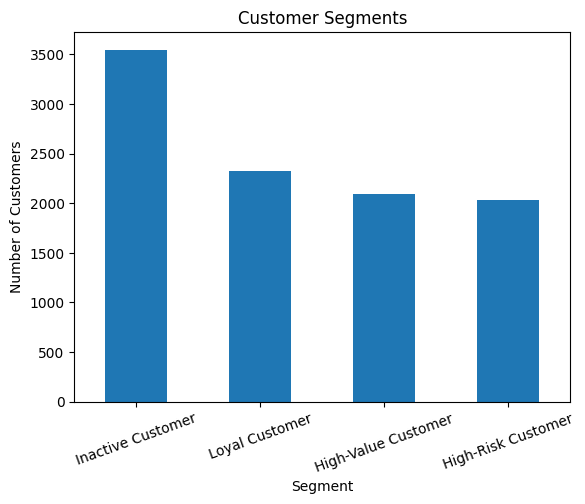

In [62]:
import matplotlib.pyplot as plt

segment_summary.plot(kind='bar')

plt.title("Customer Segments")
plt.xlabel("Segment")
plt.ylabel("Number of Customers")
plt.xticks(rotation=20)
plt.show()

# **Interpretation**
The customer segmentation divided the bank's customers into four meaningful business groups. The largest segment consists of Inactive Customers (35.47%), indicating a significant portion of customers who are not actively engaging with the bank. Loyal Customers account for 23.27%, representing a stable customer base. High-Value Customers (20.89%) contribute significantly to the bank's profitability and should be retained through personalized services. High-Risk Customers (20.37%) require immediate attention because they are more likely to leave the bank, making them the primary target for customer retention strategies.


# **Business Recommendation**

1. Re-engage inactive customers through personalized marketing campaigns.
2. Reward loyal customers with exclusive benefits.
3. Provide premium services to high-value customers.
4. Develop targeted retention programs for high-risk customers to reduce customer churn.